# Analysis
These analyses were performed on models trained using the **TF-IDF + Custom feature set**, which delivered the best performance in the Models.ipynb section.

In [19]:
import numpy as np
import pandas as pd
import joblib
import time
import joblib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = joblib.load("X_features.pkl")
y = joblib.load("y_labels.pkl")

idx = np.arange(X.shape[0])

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, idx,
    test_size=500,
    random_state=42,
    stratify=y
)

def sparse_stats(X):

    stats = {}
    if hasattr(X, "nnz"):  # scipy sparse
        stats["type"] = "sparse"
        stats["shape"] = str(X.shape)
        stats["nnz"] = int(X.nnz)
        total = X.shape[0] * X.shape[1]
        stats["density"] = float(X.nnz / total)
        
        approx_bytes = (X.data.nbytes + X.indices.nbytes + X.indptr.nbytes)
        stats["approx_mem_mb"] = float(approx_bytes / (1024**2))
    else:
        stats["type"] = "dense"
        stats["shape"] = str(X.shape)
        total = X.size
        stats["nnz"] = int(np.count_nonzero(X))
        stats["density"] = float(stats["nnz"] / total)
        stats["approx_mem_mb"] = float(X.nbytes / (1024**2))
    return stats

def benchmark_model(name, model, X_train, y_train, X_test, y_test):
    # fit time
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_s = time.perf_counter() - t0

    t1 = time.perf_counter()
    y_pred = model.predict(X_test)
    pred_s = time.perf_counter() - t1

    tmp_path = f"_tmp_{name.replace(' ', '_').lower()}.joblib"
    joblib.dump(model, tmp_path)
    import os
    model_mb = os.path.getsize(tmp_path) / (1024**2)
    os.remove(tmp_path)

    return {
        "Model": name,
        "Fit time (s)": fit_s,
        "Predict time (s)": pred_s,
        "Model size (MB)": model_mb
    }


train_stats = sparse_stats(X_train)
test_stats  = sparse_stats(X_test)

print("=== Feature Matrix Stats ===")
print("X_train:", train_stats)
print("X_test :", test_stats)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = [
    ("Logistic Regression", Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(max_iter=3000))
    ])),
    ("Linear SVM", Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LinearSVC(max_iter=20000))
    ])),
    ("Random Forest", RandomForestClassifier(n_estimators=200, random_state=42)),
    ("MLP", Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", MLPClassifier(hidden_layer_sizes=(128,), max_iter=50, early_stopping=True, random_state=42))
    ])),
]


rows = []
for name, mdl in models:
    rows.append(benchmark_model(name, mdl, X_train, y_train, X_test, y_test))

df_compute = pd.DataFrame(rows).sort_values("Fit time (s)", ascending=True)
df_compute

print("Train:", X_train.shape[0], "Test:", X_test.shape[0])


print("Train:", X_train.shape[0], "Test:", X_test.shape[0])
print("Class distribution (test):\n", pd.Series(y_test).value_counts())


=== Feature Matrix Stats ===
X_train: {'type': 'sparse', 'shape': '(1594, 4968)', 'nnz': 72797, 'density': 0.009192710385362178, 'approx_mem_mb': 0.8391799926757812}
X_test : {'type': 'sparse', 'shape': '(500, 4968)', 'nnz': 17366, 'density': 0.006991143317230274, 'approx_mem_mb': 0.20064926147460938}
Train: 1594 Test: 500
Train: 1594 Test: 500
Class distribution (test):
 1    289
0    211
Name: count, dtype: int64


## ROC Curve and AUC
Probability scores for the Logistic Regression model are obtained using the `predict_proba` method, while classification scores for the Linear SVM model are calculated using the `decision_function`.

AUC: 0.9013102871480345


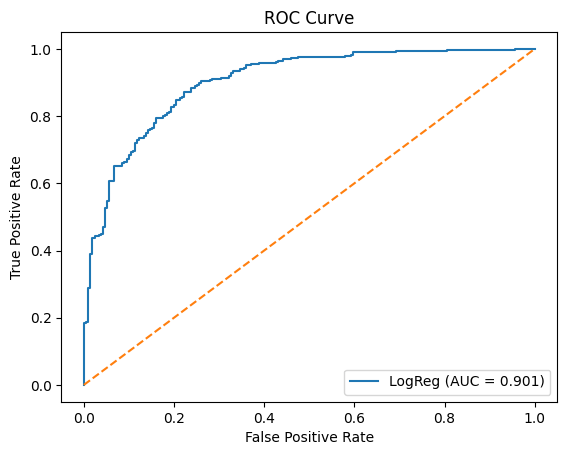

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Logistic Regression 
log_reg = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=3000))
])

log_reg.fit(X_train, y_train)
y_proba = log_reg.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"LogReg (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


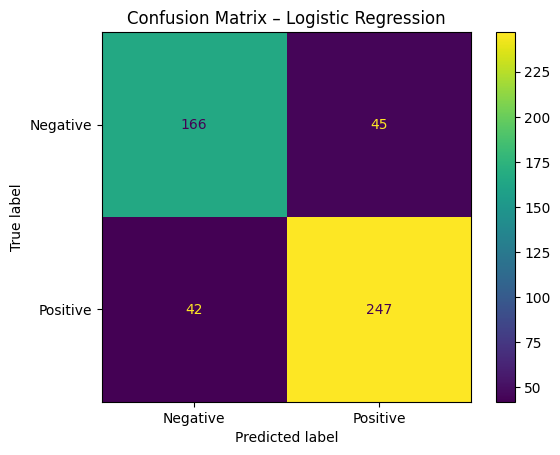

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = log_reg.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])

disp.plot()
plt.title("Confusion Matrix – Logistic Regression")
plt.show()


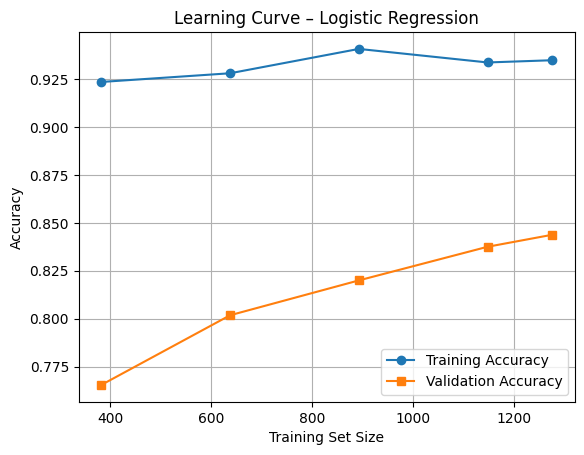

In [22]:
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

log_reg = LogisticRegression(max_iter=3000)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    log_reg,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    train_sizes=[0.3, 0.5, 0.7, 0.9, 1.0],
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o", label="Training Accuracy")
plt.plot(train_sizes, val_mean, marker="s", label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve – Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()


In [23]:
df_text = pd.read_csv("final_Data.csv", encoding="utf-8-sig")
df_text = df_text.reset_index(drop=True)
print(df_text.columns)
df_text[["Yorum", "clean_text", "label"]].head()


Index(['Puan', 'Yorum', 'label', 'clean_text', 'question_count', 'upper_ratio',
       'avg_word', 'positive_count', 'negation_count', 'exclamation_count',
       'char_count'],
      dtype='object')


,Yorum,clean_text,label
0,Hayatımda en çok içimi acıtan ağlata ağlata yü...,hayatımda içimi acıtan ağlata ağlata yüreğimi ...,1
1,Şimdiye kadar Salya sümük ağladığım tek film t...,şimdiye kadar salya sümük ağladığım tek film t...,1
2,Anlamadığım su yok ordan calinmis yok ona benz...,anlamadığım su yok ordan calinmis yok ona benz...,1
3,Filmi dün izledim. Gitmeden önce hiçbir tavsiy...,filmi dün izledim gitmeden önce hiçbir tavsiye...,1
4,"Filmi ağlayarak mı izlemek ,az kalan bir cümle...",filmi ağlayarak izlemek kalan bir cümleiçiniz ...,1


In [24]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=3000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

wrong_mask = (y_pred != y_test)
wrong_indices = idx_test[wrong_mask]

print("Wrong predictions:", wrong_mask.sum())

for i, ridx in enumerate(wrong_indices[:5], 1):
    print("\n" + "="*50)
    print(f"Example {i}")
    print("True label:", df_text.loc[ridx, "label"])
    print("Predicted:", y_pred[wrong_mask][i-1])
    print("Text:", df_text.loc[ridx, "Yorum"][:300])


Wrong predictions: 68

Example 1
True label: 0
Predicted: 1
Text: Kartal Tibet'ten daha iyisini beklerdim.Mehmet Ali Erbilin oynaması zaten büyük bir hata.Komedi yerine aslına daha uygun bir film çekseler çok daha güzel olabilirdi.Tamam ilk film çok abartı ama sinema tarihine geçmiştir.Bu ise hafızalarda asla yer edemez.

Example 2
True label: 0
Predicted: 1
Text: gizliden gizliye siyasi propaganda yapan bir film. sırf bu yüzden her zaman için sevmemişimdir. ve sevmeyeceğim. filmin vermek istediği mesajla paralel bir siyasi duruşum olmasına karşın hakettiğinden fazla ilgi gören, siyasi propaganda filmi.

Example 3
True label: 1
Predicted: 0
Text: Herkes veled diyecek bunu biliyorum ama Recep İvedik çıktığı zaman herkes koşa koşa gitti yine ona benzer bir film varken neden kimse beğenmiyor

Example 4
True label: 0
Predicted: 1
Text: İlk olarak olumlu yorum yapıcam:zaten bildiğimiz tanıdığımız oyunculuğa yıllarını vermiş oyuncularımız çok iyi bir iş çıkarmış.özellikle aras bulut.AMA yan 

## 5. Regularization & Overfitting Prevention

In this section, we demonstrate overfitting prevention using:
1) L1/L2 regularization (Logistic Regression)
2) Early stopping (MLP)
3) (Optional) Feature selection (SelectKBest) as an additional technique

We also connect results to the learning curve and bias–variance trade-off.


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd
import numpy as np

y = np.ravel(y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Cs = [0.01, 0.1, 1, 10]

rows = []

# ---- L2 ----
for C in Cs:
    clf = LogisticRegression(
        C=C,
        solver="liblinear",   
        max_iter=3000,
        random_state=42
    )
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    rows.append({"Reg": "L2", "C": C, "acc_mean": scores.mean(), "acc_std": scores.std()})

# ---- L1 ----
for C in Cs:
    clf = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",  
        max_iter=3000,
        random_state=42
    )
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    rows.append({"Reg": "L1", "C": C, "acc_mean": scores.mean(), "acc_std": scores.std()})

df_reg = (pd.DataFrame(rows)
          .sort_values(["Reg", "acc_mean"], ascending=[True, False])
          .reset_index(drop=True))

df_reg


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning:

,Reg,C,acc_mean,acc_std
0,L1,10.00,0.841902,0.010118
1,L1,1.00,0.799882,0.032620
2,L1,0.10,0.617939,0.010095
3,L1,0.01,0.579046,0.001233
4,L2,10.00,0.856957,0.014587
5,L2,1.00,0.842529,0.012830
6,L2,0.10,0.755953,0.020242
7,L2,0.01,0.616685,0.008589


In [26]:
import time
import pandas as pd

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def eval_mlp(early_stopping_flag: bool):
    mlp = MLPClassifier(
        hidden_layer_sizes=(128,),
        max_iter=100,
        early_stopping=early_stopping_flag, 
        n_iter_no_change=10,
        random_state=42
    )
    t0 = time.perf_counter()
    mlp.fit(X_train, y_train)
    fit_s = time.perf_counter() - t0

    y_pred = mlp.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)

    return {
        "MLP early_stopping": early_stopping_flag,
        "Fit time (s)": fit_s,
        "Accuracy": acc,
        "F1 (weighted)": f1,
        "Iterations used": getattr(mlp, "n_iter_", None)
    }

df_es = pd.DataFrame([eval_mlp(False), eval_mlp(True)])
df_es

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,MLP early_stopping,Fit time (s),Accuracy,F1 (weighted),Iterations used
0,False,3.872111,0.838,0.833939,100
1,True,1.998375,0.856,0.856254,43


In [27]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

selector = SelectKBest(chi2, k=2000)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

base = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=3000))
])
base.fit(X_train, y_train)

sel = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=3000))
])
sel.fit(X_train_sel, y_train)


print("Base Accuracy:", accuracy_score(y_test, base.predict(X_test)))
print("Feature-Selected Accuracy:", accuracy_score(y_test, sel.predict(X_test_sel)))


Base Accuracy: 0.826
Feature-Selected Accuracy: 0.822
